In [ ]:
# 既にインストールされていれば不要
!pip install stim

In [2]:
import stim
import numpy as np
import matplotlib.pyplot as plt

# グラフのスタイル設定
plt.rcParams['font.size'] = 12

# スティーン符号のパリティ検査行列 H (復号用)
H_MATRIX = np.array([
[0, 0, 0, 1, 1, 1, 1],
[0, 1, 1, 0, 0, 1, 1],
[1, 0, 1, 0, 1, 0, 1]
])

def decode_steane(measurement_result):
    """スティーン符号のシンドローム計算と誤り訂正を行い，論理ビットに対する測定結果を復元する関数"""
    syndrome = (H_MATRIX @ measurement_result) % 2
    error_idx_plus_1 = syndrome[0]*4 + syndrome[1]*2 + syndrome[2]
    corrected = measurement_result.copy()
    if error_idx_plus_1 > 0:
        idx = int(error_idx_plus_1 - 1)
        corrected[idx] = (corrected[idx] + 1) % 2
    return np.sum(corrected) % 2

In [3]:
def get_transversal_op_circuit(p):
    """トランスバーサルな論理X操作の回路生成"""
    circuit = stim.Circuit()
    q = list(range(7))

    # 1. 完全な論理|0_L>を用意
    circuit.append("R", q)
    circuit.append("H", [1, 2, 3])
    circuit.append("CX", [1, 0, 3, 5, 2, 6, 1, 4, 2, 0, 3, 6, 1, 5, 6, 4])
    circuit.append("TICK")

    # 2. トランスバーサルなX操作(各ビットにX)
    # ここでのゲート操作自体にノイズが乗る
    circuit.append("X", q[:3])
    circuit.append("DEPOLARIZE1", q[:3], p) # 各ゲート後に独立にエラー

    # 3. 測定(Z基底)
    circuit.append("M", q)
    return circuit

def get_non_transversal_op_circuit(p):
    """非トランスバーサルな操作の回路生成．
    あえてエラーが広がりやすい方法で論理Xゲートを実装する．
    """
    circuit = stim.Circuit()
    q = list(range(7))

    # 1. 完全な論理|0_L>を用意
    circuit.append("R", q)
    circuit.append("H", [1, 2, 3])
    circuit.append("CX", [1, 0, 3, 5, 2, 6, 1, 4, 2, 0, 3, 6, 1, 5, 6, 4])
    circuit.append("TICK")

    # 2. 非トランスバーサルな論理X操作
    circuit.append("CX", [0, 2])
    circuit.append("DEPOLARIZE2", [0, 2], p)
    circuit.append("CX", [0, 1])
    circuit.append("DEPOLARIZE2", [0, 1], p)
    circuit.append("X", [0])
    circuit.append("DEPOLARIZE1", [0], p)
    circuit.append("CX", [0, 1])
    circuit.append("DEPOLARIZE2", [0, 1], p)
    circuit.append("CX", [0, 2])
    circuit.append("DEPOLARIZE2", [0, 2], p)

    # 3. 測定
    circuit.append("M", q)
    return circuit

def run_simulation(circuit_func, p, shots=50000):
    circuit = circuit_func(p)
    results = circuit.compile_sampler().sample(shots)
    failures = 0
    for res in results:
        # 論理|0>にX操作-> 論理|1>(パリティ1)になるはず．0なら失敗
        if decode_steane(res) == 0:
            failures += 1
    return failures / shots

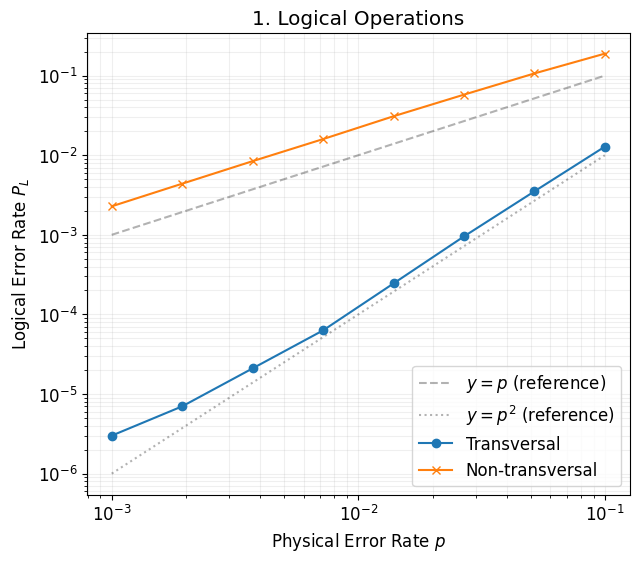

In [4]:
probs = np.logspace(-3, -1, 8)

# データの収集
shots = 1_000_000
y_transversal = [run_simulation(get_transversal_op_circuit, p, shots) for p in probs]
y_non_transversal = [run_simulation(get_non_transversal_op_circuit, p, shots) for p in probs]

# プロット
plt.figure(figsize=(7, 6))
plt.loglog(probs, probs, 'k--', alpha=0.3, label="$y=p$ (reference)")
plt.loglog(probs, probs**2, 'k:', alpha=0.3, label="$y=p^2$ (reference)")
plt.loglog(probs, y_transversal, 'o-', label="Transversal")
plt.loglog(probs, y_non_transversal, 'x-', label="Non-transversal")
plt.xlabel("Physical Error Rate $p$")
plt.ylabel("Logical Error Rate $P_L$")
plt.title("1. Logical Operations")
plt.legend()
plt.grid(True, which="both", alpha=0.2)
plt.show()

In [5]:
def encode_steane(circuit, p):
    """スティーン符号のエンコード回路を生成する関数"""
    # ノイズ付きエンコード回路
    circuit.append("H", [1, 2, 3])
    circuit.append("DEPOLARIZE1", [1, 2, 3], p)
    # CNOTs (ノイズ付き)
    pairs = [(1, 0), (3, 5), (2, 6), (1, 4), (2, 0), (3, 6), (1, 5), (6, 4)]
    for c, t in pairs:
        circuit.append("CX", [c, t])
        circuit.append("DEPOLARIZE2", [c, t], p)
    circuit.append("TICK")
    return circuit

def get_naive_prep_circuit(p):
    """愚直なエンコード後に測定"""
    circuit = stim.Circuit()
    q = list(range(7))
    circuit.append("R", q)
    circuit = encode_steane(circuit, p)
    # 測定(Z基底)
    circuit.append("M", q)
    return circuit

def get_state_prep_ft(p):
    """後藤のフォールトトレラントなエンコード回路"""
    circuit = stim.Circuit()
    q = list(range(7))

    # ステップ1: 各量子ビットを初期化
    circuit.append("R", q)

    # ステップ2: スティーン符号のエンコード回路を適用
    circuit = encode_steane(circuit, p)

    # ステップ3: シンドローム測定とポストセレクション
    # ポストセレクションのための追加CNOTs (ノイズ付き)
    circuit.append("R", [7])
    pairs = [(0, 7), (5, 7), (6, 7)]
    for c, t in pairs:
        circuit.append("CX", [c, t])
        circuit.append("DEPOLARIZE2", [c, t], p)
    circuit.append("M", [7])
    circuit.append("TICK")

    circuit.append("M", q) # 結果の検証のための測定
    return circuit

In [6]:
def run_state_prep_naive(p, shots=50000):
    """愚直な状態生成のシミュレーション"""
    circuit = get_naive_prep_circuit(p)
    results = circuit.compile_sampler().sample(shots)
    failures = 0
    for res in results:
        # 単純に復号してエラー判定
        if decode_steane(res) == 1:
            failures += 1
    return failures / shots

def run_state_prep_ft(p, shots=50000):
    """フォールトトレラントな状態生成(ポストセレクションあり)のシミュレーション"""
    circuit = get_state_prep_ft(p)
    results = circuit.compile_sampler().sample(shots)

    failures = 0 # 論理エラー数
    valid_shots = 0 # ポストセレクションに成功したサンプル数

    for res in results:
        flag = res[0] # ポストセレクション用のフラグビット
        data = res[1:] # データビット
        # ポストセレクション: フラグが0(エラー未検出) の場合のみ採用
        if flag == 0:
            valid_shots += 1
            # 採用したデータの中で，論理値が誤っているものをカウント
            if decode_steane(data) == 1:
                failures += 1
    # ポストセレクションに成功したサンプル数を分母とすることに注意
    return failures / valid_shots

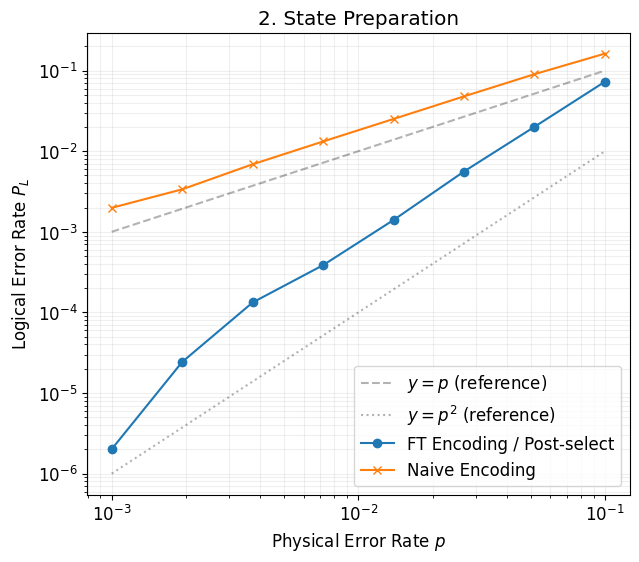

In [7]:
# データの収集
shots = 500_000
y_naive_prep = [run_state_prep_naive(p, shots) for p in probs]
y_ft_prep = [run_state_prep_ft(p, shots) for p in probs]

# プロット
plt.figure(figsize=(7, 6))
plt.loglog(probs, probs, 'k--', alpha=0.3, label="$y=p$ (reference)")
plt.loglog(probs, probs**2, 'k:', alpha=0.3, label="$y=p^2$ (reference)")
plt.loglog(probs, y_ft_prep, 'o-', label="FT Encoding / Post-select")
plt.loglog(probs, y_naive_prep, 'x-', label="Naive Encoding")
plt.xlabel("Physical Error Rate $p$")
plt.ylabel("Logical Error Rate $P_L$")
plt.title("2. State Preparation")
plt.legend()
plt.grid(True, which="both", alpha=0.2)
plt.show()